# Advanced ML Pipeline: Comprehensive Scenario Diagnosis, Charts, and Remediation Recommendations

This notebook covers the full ML pipeline of the Multimodal RCA Engine:

| Step | Topic |
|------|------|
| 1 | Environment Setup and Data Loading |
| 2 | XGBoost and LightGBM Anomaly Detection + Comparison Charts |
| 3 | RCA Multi-Class Models (Random Forest) |
| 4 | Live Tests — 22 Anomaly Scenarios + Normal Cases |
| 5 | Constructive Diagnosis Messages and Remediation Steps |
| 6 | Diagnosis Charts |
| 7 | SHAP Explainability Analysis |
| 8 | Overfitting Analysis — Train/Val/Test + Cross-Validation + Regularized Model |
| 9 | Comprehensive Study Summary |

## 1 — Environment Setup and Libraries

We import all required libraries and add the project modules to the path.

In [1]:
import sys, yaml, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from datetime import datetime
from collections import defaultdict

warnings.filterwarnings('ignore')

sys.path.insert(0, r"d:\multimodal-rca-engine")

from models.data_loader import MultimodalDataLoader
from models.rca_models import RemediationEngine
import xgboost as xgb
import lightgbm as lgb
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix,
    classification_report
)

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

print(f"XGBoost  : {xgb.__version__}")
print(f"LightGBM : {lgb.__version__}")
print(f"SHAP     : {shap.__version__}")
print("All libraries loaded successfully.")

XGBoost  : 3.0.5
LightGBM : 4.6.0
SHAP     : 0.48.0
All libraries loaded successfully.


### Loading the Anomaly Scenario Catalog

We read the definitions of the 22 anomaly scenarios, their root cause information, and
remediation steps from `configs/anomaly_scenarios.yaml`.

In [2]:
def load_scenario_catalog():
    yaml_path = Path(r"d:\multimodal-rca-engine\configs\anomaly_scenarios.yaml")
    with open(yaml_path, 'r', encoding='utf-8') as f:
        cfg = yaml.safe_load(f)
    catalog = {}
    for layer_key, layer_data in cfg.get('layers', {}).items():
        for sc in layer_data.get('scenarios', []):
            catalog[sc['id']] = {
                'id':           sc['id'],
                'name':         sc['name'],
                'name_tr':      sc.get('name_tr', sc['name']),
                'description':  sc.get('description', ''),
                'layer':        layer_key,
                'layer_name':   layer_data.get('name', layer_key),
                'layer_tr':     layer_data.get('name_tr', layer_key),
                'root_cause':   sc.get('root_cause', ''),
                'root_cause_tr':sc.get('root_cause_tr', ''),
                'root_cause_category': sc.get('root_cause_category', ''),
                'severity':     sc.get('severity', 'medium'),
                'remediation':  sc.get('remediation', []),
                'anomaly_type': sc.get('anomaly_type', ''),
                'detection_params': sc.get('detection_params', []),
            }
    return catalog

catalog = load_scenario_catalog()
print(f"Number of loaded scenarios: {len(catalog)}")

# Catalog summary
rows = []
for sc_id, info in sorted(catalog.items()):
    rows.append({
        'ID':       sc_id,
        'Name':     info['name'],
        'Layer':    info['layer_name'],
        'Severity': info['severity'],
        'Anomaly Type': info['anomaly_type'],
    })
df_catalog = pd.DataFrame(rows)
display(df_catalog)

Number of loaded scenarios: 22


,ID,Name,Layer,Severity,Anomaly Type
0,APP_001,Processing Time Increase,Application Layer,high,gradual_rise
1,APP_002,Error Rate Increase,Application Layer,critical,spike
2,CDN_001,Sudden Traffic Spike,CDN,critical,spike
3,CDN_002,Response Time Increase,CDN,high,gradual_rise
4,DB_001,Slow Query Increase,Database,high,gradual_rise
5,DB_002,Connection Count Increase,Database,critical,spike
6,FW_001,Increased Blocked Connections,Firewall,high,spike
7,FW_002,High Bandwidth Usage,Firewall,high,sustained_high
8,HOST_001,CPU Temperature Increase,Linux Host (Physical Machine),critical,gradual_rise
9,HOST_002,Disk Error Count Increase,Linux Host (Physical Machine),critical,step_increase


### Loading and Splitting the Dataset

The 10,000-sample multimodal dataset is loaded and split as **Train 70% / Validation 10% / Test 20%**.

In [3]:
dataset_dir = Path(r"d:\multimodal-rca-engine\data\multimodal_dataset")
loader = MultimodalDataLoader(
    dataset_dir=dataset_dir, noise_level=0.15, feature_dropout=0.05, seed=42
)
data   = loader.build_feature_matrix(max_samples=10000, include_tfidf=False)
splits = loader.split_data(data, test_size=0.2, val_size=0.1, random_state=42)

train_split = splits['train']
val_split   = splits['val']
test_split  = splits['test']

def combine(s):
    return np.hstack([s['X_metrics'].values, s['X_logs'].values])

X_train, y_train = combine(train_split), train_split['y_anomaly']
X_val,   y_val   = combine(val_split),   val_split['y_anomaly']
X_test,  y_test  = combine(test_split),  test_split['y_anomaly']

metric_names = [f'm{p}_{s}' for p in range(8)
                for s in ['mean','std','min','max','range','median',
                          'skew','kurtosis','slope','spike','change','volatility','autocorr']]
log_names    = ['log_total_lines','log_info_count','log_warn_count','log_error_count',
                'log_critical_count','log_error_ratio','log_warn_ratio',
                'log_critical_ratio','log_severity_score']
feature_names = metric_names + log_names

print(f"Train   : {X_train.shape[0]:,} samples")
print(f"Test    : {X_test.shape[0]:,} samples")
print(f"Number of features: {len(feature_names)}")

 Loaded metadata: 10,000 samples
   Normal:  5,000
   Anomaly: 5,000

 Building feature matrix for 10,000 samples...


   Processed 2,000/10,000 samples...


   Processed 4,000/10,000 samples...


   Processed 6,000/10,000 samples...


   Processed 8,000/10,000 samples...


   Processed 10,000/10,000 samples...
    Extracted features for 10,000 samples (skipped 0)


    Applying noise (level=0.15, dropout=0.05)...
    y_root_cause: 6 classes → [np.str_('config'), np.str_('hardware'), np.str_('network'), np.str_('none'), np.str_('resource'), np.str_('software')]
    y_severity: 4 classes → [np.str_('critical'), np.str_('high'), np.str_('medium'), np.str_('none')]
    y_layer: 11 classes → [np.str_('application'), np.str_('cdn'), np.str_('database'), np.str_('firewall'), np.str_('kubernetes_deployments'), np.str_('kubernetes_ingress'), np.str_('linux_host'), np.str_('linux_vm'), np.str_('network'), np.str_('proxy'), np.str_('storage')]
    y_scenario: 23 classes → [np.str_('APP_001'), np.str_('APP_002'), np.str_('CDN_001'), np.str_('CDN_002'), np.str_('DB_001'), np.str_('DB_002'), np.str_('FW_001'), np.str_('FW_002'), np.str_('HOST_001'), np.str_('HOST_002'), np.str_('K8D_001'), np.str_('K8D_002'), np.str_('K8I_001'), np.str_('K8I_002'), np.str_('NET_001'), np.str_('NET_002'), np.str_('PRX_001'), np.str_('PRX_002'), np.str_('STR_001'), np.str_('STR_

Train   : 7,000 samples
Test    : 2,000 samples
Number of features: 113


## 2 — Model Training: XGBoost and LightGBM

Two strong gradient boosting models are trained for binary anomaly detection (Normal=0, Anomaly=1).

In [4]:
print("Starting XGBoost training...")
xgb_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
xgb_model.fit(X_train, y_train)
print("XGBoost training complete.")

print("Starting LightGBM training...")
lgb_model = lgb.LGBMClassifier(
    n_estimators=200, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbose=-1
)
lgb_model.fit(X_train, y_train)
print("LightGBM training complete.")

Starting XGBoost training...


XGBoost training complete.
Starting LightGBM training...


LightGBM training complete.


### Performance Comparison Table

In [5]:
def calc_metrics(model, X, y, name):
    yp = model.predict(X)
    yb = model.predict_proba(X)[:, 1]
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y, yp), 4),
        'Precision': round(precision_score(y, yp, zero_division=0), 4),
        'Recall':    round(recall_score(y, yp, zero_division=0), 4),
        'F1-Score':  round(f1_score(y, yp, zero_division=0), 4),
        'AUC-ROC':   round(roc_auc_score(y, yb), 4),
    }

df_perf = pd.DataFrame([
    calc_metrics(xgb_model, X_test, y_test, 'XGBoost'),
    calc_metrics(lgb_model,  X_test, y_test, 'LightGBM'),
]).set_index('Model')

display(df_perf.style.highlight_max(color="#0f2113", axis=0).format('{:.4f}'))

,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Model,,,,,
XGBoost,0.9875,0.9880,0.9870,0.9875,0.9994
LightGBM,0.9905,0.9910,0.9900,0.9905,0.9994


### ROC Curve and Confusion Matrix

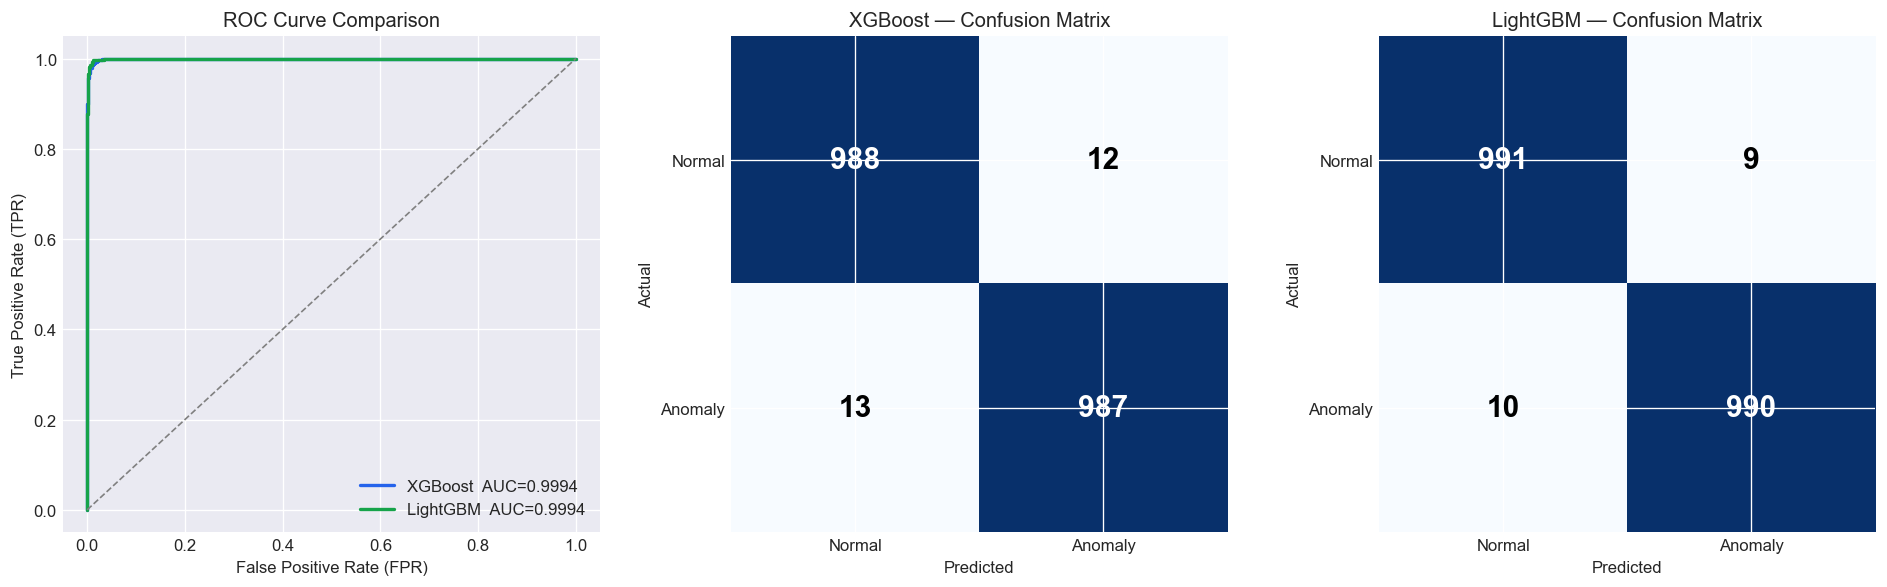

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ROC
ax = axes[0]
for name, m, c in [('XGBoost', xgb_model, '#2563eb'), ('LightGBM', lgb_model, '#16a34a')]:
    fpr, tpr, _ = roc_curve(y_test, m.predict_proba(X_test)[:,1])
    auc = roc_auc_score(y_test, m.predict_proba(X_test)[:,1])
    ax.plot(fpr, tpr, color=c, lw=2, label=f'{name}  AUC={auc:.4f}')
ax.plot([0,1],[0,1],'--', color='gray', lw=1)
ax.set_xlabel('False Positive Rate (FPR)')
ax.set_ylabel('True Positive Rate (TPR)')
ax.set_title('ROC Curve Comparison')
ax.legend(loc='lower right')

# Confusion matrices
for ax, (name, model) in zip(axes[1:], [('XGBoost', xgb_model), ('LightGBM', lgb_model)]):
    cm = confusion_matrix(y_test, model.predict(X_test))
    ax.imshow(cm, cmap='Blues')
    ax.set_title(f'{name} — Confusion Matrix')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Normal','Anomaly'])
    ax.set_yticklabels(['Normal','Anomaly'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                    fontsize=18, fontweight='bold',
                    color='white' if cm[i,j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.show()

## 3 — Root Cause Analysis (RCA) — Multi-Class Models

We train **Random Forest** models that predict Root Cause, Layer, Severity, and Scenario
on anomaly samples only.

In [7]:
anom_mask_tr = y_train == 1
anom_mask_te = y_test  == 1
X_tr_anom    = X_train[anom_mask_tr]
X_te_anom    = X_test[anom_mask_te]

le         = loader.label_encoders
rca_models = {}
rca_perf   = []

for key, label in [('root_cause','Root Cause'),('layer','Layer'),
                    ('severity','Severity'),('scenario','Scenario')]:
    y_tr = train_split[f'y_{key}'][anom_mask_tr]
    y_te = test_split[f'y_{key}'][anom_mask_te]
    n    = len(np.unique(y_tr))
    rf   = RandomForestClassifier(
        n_estimators=150, max_depth=18,
        class_weight='balanced', random_state=42, n_jobs=-1
    )
    rf.fit(X_tr_anom, y_tr)
    rca_models[key] = rf
    yp   = rf.predict(X_te_anom)
    acc  = accuracy_score(y_te, yp)
    f1m  = f1_score(y_te, yp, average='macro', zero_division=0)
    rca_perf.append({'Task': label, 'Num Classes': n,
                     'Accuracy': round(acc,4), 'F1-Macro': round(f1m,4)})
    print(f"{label:<18} ({n:2d} classes)  Accuracy={acc:.4f}  F1-Macro={f1m:.4f}")

display(pd.DataFrame(rca_perf).set_index('Task'))

Root Cause         ( 5 classes)  Accuracy=0.9800  F1-Macro=0.9784


Layer              (11 classes)  Accuracy=0.9920  F1-Macro=0.9920


Severity           ( 3 classes)  Accuracy=0.9670  F1-Macro=0.9563


Scenario           (22 classes)  Accuracy=0.9820  F1-Macro=0.9826


,Num Classes,Accuracy,F1-Macro
Task,,,
Root Cause,5,0.980,0.9784
Layer,11,0.992,0.9920
Severity,3,0.967,0.9563
Scenario,22,0.982,0.9826


## 4 — Live Tests — 22 Anomaly Scenarios + Normal Cases

From the test set we pick 1 sample from each unique anomaly scenario (22 scenarios total)
and add 3 normal samples. For each case:

- The anomaly status and confidence score are determined
- The affected layer, root cause, and scenario are identified
- An explanatory message is generated based on the anomaly type
- Prioritized remediation steps are listed

In [8]:
SEVERITY_CONFIG = {
    'critical': {'label': '[CRITICAL]', 'priority': 1, 'sla': '15 minutes', 'color': '#dc2626'},
    'high':     {'label': '[HIGH]',     'priority': 2, 'sla': '1 hour',     'color': '#ea580c'},
    'medium':   {'label': '[MEDIUM]',   'priority': 3, 'sla': '4 hours',    'color': '#ca8a04'},
    'low':      {'label': '[LOW]',      'priority': 4, 'sla': '24 hours',   'color': '#16a34a'},
    'normal':   {'label': '[NORMAL]',   'priority': 5, 'sla': '---',        'color': '#22c55e'},
}

def build_diagnosis_message(sc_info, prob, is_anomaly):
    if not is_anomaly:
        return {
            'status':      'SYSTEM NORMAL',
            'explanation': ('All metrics are moving within the expected thresholds. '
                            'Log error rates, metric fluctuations, and infrastructure health '
                            'are in the normal range. No intervention is required.'),
            'risk':        f'{(1-prob)*100:.1f}% (Normal)',
            'sla':         '---',
            'priority':    5,
            'color':       '#22c55e',
        }
    sev = sc_info.get('severity', 'medium')
    cfg = SEVERITY_CONFIG.get(sev, SEVERITY_CONFIG['medium'])
    risk_score = round(float(prob) * 100, 1)

    parts = [
        f"Scenario '{sc_info.get('name','')}' detected on the '{sc_info.get('layer_name','')}' layer.",
        f"Root cause analysis indicates this is caused by '{sc_info.get('root_cause','')}'.",
        f"The system anomaly probability was computed at {risk_score}% confidence.",
    ]
    atype = sc_info.get('anomaly_type', '')
    type_msgs = {
        'spike':         ('A sudden, sharp jump was observed in the measurements; '
                          'this may indicate an unexpected load surge or an attack.'),
        'gradual_rise':  ('Values are increasing gradually over time; '
                          'a typical pattern indicating resource exhaustion or configuration drift.'),
        'sustained_high':('Values have remained high for a long time; '
                          'sustained anomalies usually signal a structural problem.'),
        'oscillation':   ('Irregular oscillation is observed; '
                          'it may be caused by load-balancer errors or configuration inconsistencies.'),
        'step_increase': ('A step increase was detected; '
                          'it may indicate hardware degradation or a fault in a critical system component.'),
        'sudden_drop':   ('Values show a sudden drop; '
                          'the possibility of a service outage or resource shortage should be investigated.'),
    }
    if atype in type_msgs:
        parts.append(type_msgs[atype])
    dp = sc_info.get('detection_params', [])
    if dp:
        parts.append(f"Triggering metrics: {', '.join(dp)}.")
    return {
        'status':      cfg['label'],
        'explanation': ' '.join(parts),
        'risk':        f'{risk_score}%',
        'sla':         f"Response SLA: {cfg['sla']}",
        'priority':    cfg['priority'],
        'color':       cfg['color'],
    }

def build_remediation_steps(rem_list, sev, sc_id):
    base = rem_list if rem_list else ['Notify the system administrator.']
    detail_map = {
        'restart':  'Check active connections before stopping the service. Inspect the log files after the restart.',
        'script':   'Run the script with root privileges. Redirect its output to a log file and verify it completed successfully.',
        'block':    'When applying a blocking rule, perform a whitelist check to avoid conflicts with legitimate traffic.',
        'backup':   'Verify the integrity of the backup. Do not proceed to a hardware change before the backup is complete.',
        'monitor':  'Take measurements at 5-minute intervals and record the trends.',
        'clean':    'Before cleanup, list which files will be deleted and obtain approval.',
        'scale':    'During scaling, use a rolling update to minimize the current downtime.',
        'analyz':   'Record the traffic for 15 minutes and compare it against attack signatures.',
        'optim':    'Before optimization, set a measurable improvement target based on current performance metrics.',
    }
    default_detail = 'Continuously monitor the system status while applying this step.'

    steps = [{'step': 0, 'action': f'[PREP] Create the incident record; document the timestamp and scenario code ({sc_id}).',
               'priority': 'PRIORITY',
               'detail': 'Notify the relevant system administrators and the NOC team. Record the observation logs.'}]
    for i, action in enumerate(base, 1):
        detail = default_detail
        for keyword, d in detail_map.items():
            if keyword in action.lower():
                detail = d; break
        pr = 'CRITICAL' if sev == 'critical' and i == 1 else 'STANDARD'
        steps.append({'step': i, 'action': f'[ACTION {i}] {action}',
                      'priority': pr, 'detail': detail})
    steps.append({'step': len(steps),
                  'action': '[VERIFICATION] Check the impact of the applied remediations.',
                  'priority': 'CLOSURE',
                  'detail': ('After the remediation steps, monitor the metrics for 10-15 minutes. '
                             'If the anomaly values fall below the normal threshold, close the incident. '
                             'If it persists, escalate to the L2/L3 support team.')})
    return steps

print('Diagnosis functions loaded.')

Diagnosis functions loaded.


In [9]:
# Select test samples — 1 sample per unique scenario + 3 normal
sc_le        = le['y_scenario']
layer_le     = le['y_layer']
rc_le        = le['y_root_cause']
sev_le       = le['y_severity']

anom_idxs   = np.where(y_test == 1)[0]
normal_idxs = np.where(y_test == 0)[0]

test_sc_names = sc_le.inverse_transform(test_split['y_scenario'][anom_idxs])
seen, sel_anom = set(), []
for raw_idx, sc_name in zip(anom_idxs, test_sc_names):
    if sc_name != 'none' and sc_name not in seen:
        seen.add(sc_name)
        sel_anom.append(raw_idx)
    if len(sel_anom) >= 22:
        break

sel_normal = list(normal_idxs[:3])
all_cases  = [('NORMAL', i) for i in sel_normal] + [('ANOMALY', i) for i in sel_anom]

print(f"Number of selected cases: {len(all_cases)}  (Normal: {len(sel_normal)}, Anomaly: {len(sel_anom)})")

Number of selected cases: 25  (Normal: 3, Anomaly: 22)


In [10]:
# Diagnose all cases and collect the results
results      = []
severity_cnt = defaultdict(int)
scenario_hits= defaultdict(int)

for case_type, idx in all_cases:
    x        = X_test[idx].reshape(1, -1)
    is_anom  = xgb_model.predict(x)[0]
    prob_anom= xgb_model.predict_proba(x)[0, 1]

    if is_anom:
        sc_id    = sc_le.inverse_transform([rca_models['scenario'].predict(x)[0]])[0]
        layer_id = layer_le.inverse_transform([rca_models['layer'].predict(x)[0]])[0]
        rc_id    = rc_le.inverse_transform([rca_models['root_cause'].predict(x)[0]])[0]
        sev_id   = sev_le.inverse_transform([rca_models['severity'].predict(x)[0]])[0]
        sc_info  = catalog.get(sc_id, {
            'id': sc_id, 'name': sc_id, 'description': '',
            'layer_name': layer_id, 'root_cause': rc_id,
            'root_cause_category': rc_id, 'severity': sev_id,
            'remediation': [], 'anomaly_type': '', 'detection_params': [],
        })
    else:
        sc_id, layer_id, rc_id, sev_id = 'none', '---', '---', 'normal'
        sc_info = {}

    diag  = build_diagnosis_message(sc_info, prob_anom, is_anom)
    steps = build_remediation_steps(
        sc_info.get('remediation', []), sev_id, sc_id
    ) if is_anom else []

    results.append({
        'case_type':   case_type, 'idx': idx,
        'is_anomaly':  is_anom, 'prob_anomaly': prob_anom,
        'scenario_id': sc_id, 'layer': layer_id,
        'root_cause':  rc_id, 'severity': sev_id,
        'diagnosis':   diag, 'steps': steps, 'sc_info': sc_info,
    })
    if is_anom:
        severity_cnt[sev_id] += 1
        scenario_hits[sc_id] += 1

print(f"Diagnosis complete: {len(results)} cases processed.")

Diagnosis complete: 25 cases processed.


### Diagnosis Results Summary Table

In [11]:
rows_diag = []
for r in results:
    rows_diag.append({
        'Sample #':      r['idx'],
        'Scenario':      r['scenario_id'],
        'Layer':         r['sc_info'].get('layer_name', r['layer']) if r['is_anomaly'] else 'Normal',
        'Root Cause':    r['sc_info'].get('root_cause', r['root_cause'])[:40] if r['is_anomaly'] else '---',
        'Status':        r['diagnosis']['status'],
        'Risk':          r['diagnosis']['risk'],
        'SLA':           r['diagnosis']['sla'],
    })

df_diag = pd.DataFrame(rows_diag)
display(df_diag)

,Sample #,Scenario,Layer,Root Cause,Status,Risk,SLA
0,0,none,Normal,---,SYSTEM NORMAL,100.0% (Normal),---
1,2,none,Normal,---,SYSTEM NORMAL,100.0% (Normal),---
2,4,STR_001,Storage,Insufficient disk space or log file accu,[HIGH],83.9000015258789%,Response SLA: 1 hour
3,1,FW_002,Firewall,Excessive traffic or potential data exfi,[HIGH],100.0%,Response SLA: 1 hour
4,3,VM_002,Linux VM,Memory leak or high memory demand,[CRITICAL],100.0%,Response SLA: 15 minutes
5,7,NET_001,Network,Network device issue or connectivity pro,[HIGH],99.9000015258789%,Response SLA: 1 hour
6,9,CDN_001,CDN,Potential DDoS attack or temporary spike,[CRITICAL],100.0%,Response SLA: 15 minutes
7,12,PRX_001,Proxy,Proxy configuration issue or excessive l,[HIGH],100.0%,Response SLA: 1 hour
8,13,STR_002,Storage,Disk I/O bottleneck or disk failure,[HIGH],100.0%,Response SLA: 1 hour
9,14,APP_002,Application Layer,Application or API connection error,[CRITICAL],99.4000015258789%,Response SLA: 15 minutes


## 5 — Constructive Diagnosis Messages and Remediation Steps

For each anomaly, an explanatory message and prioritized remediation steps are printed.

In [12]:
SEVERITY_COLOR = {
    'critical': '#dc2626', 'high': '#ea580c',
    'medium':   '#ca8a04', 'normal': '#16a34a', 'none': '#16a34a',
}

for r in results:
    sep = '-' * 65
    print(f"\n{sep}")
    print(f"  Sample #{r['idx']:4d}  |  {r['diagnosis']['status']}")
    print(sep)
    if r['is_anomaly']:
        sc = r['sc_info']
        print(f"  Scenario   : {r['scenario_id']} -- {sc.get('name','')}")
        print(f"  Layer      : {sc.get('layer_name', r['layer'])}")
        print(f"  Root Cause : {sc.get('root_cause', r['root_cause'])}")
        print(f"  Risk       : {r['diagnosis']['risk']}")
        print(f"  Response   : {r['diagnosis']['sla']}")
        print("")
        print("  EXPLANATION:")
        words = r['diagnosis']['explanation'].split()
        line, lines_out = [], []
        for w in words:
            line.append(w)
            if len(' '.join(line)) > 60:
                lines_out.append('    ' + ' '.join(line[:-1]))
                line = [w]
        if line: lines_out.append('    ' + ' '.join(line))
        print('\n'.join(lines_out))
        print("")
        print("  REMEDIATION STEPS:")
        for s in r['steps']:
            print(f"    [{s['priority']:<12}] {s['action']}")
            print(f"               -> {s['detail'][:80]}..." if len(s['detail'])>80 else f"               -> {s['detail']}")
    else:
        print(f"  Risk  : Low | Confidence: {r['diagnosis']['risk']}")
        print(f"  Status: {r['diagnosis']['explanation'][:120]}")


-----------------------------------------------------------------
  Sample #   0  |  SYSTEM NORMAL
-----------------------------------------------------------------
  Risk  : Low | Confidence: 100.0% (Normal)
  Status: All metrics are moving within the expected thresholds. Log error rates, metric fluctuations, and infrastructure health a

-----------------------------------------------------------------
  Sample #   2  |  SYSTEM NORMAL
-----------------------------------------------------------------
  Risk  : Low | Confidence: 100.0% (Normal)
  Status: All metrics are moving within the expected thresholds. Log error rates, metric fluctuations, and infrastructure health a

-----------------------------------------------------------------
  Sample #   4  |  [HIGH]
-----------------------------------------------------------------
  Scenario   : STR_001 -- High Disk Usage
  Layer      : Storage
  Root Cause : Insufficient disk space or log file accumulation
  Risk       : 83.9%
  Respons

## 6 — Diagnosis Charts

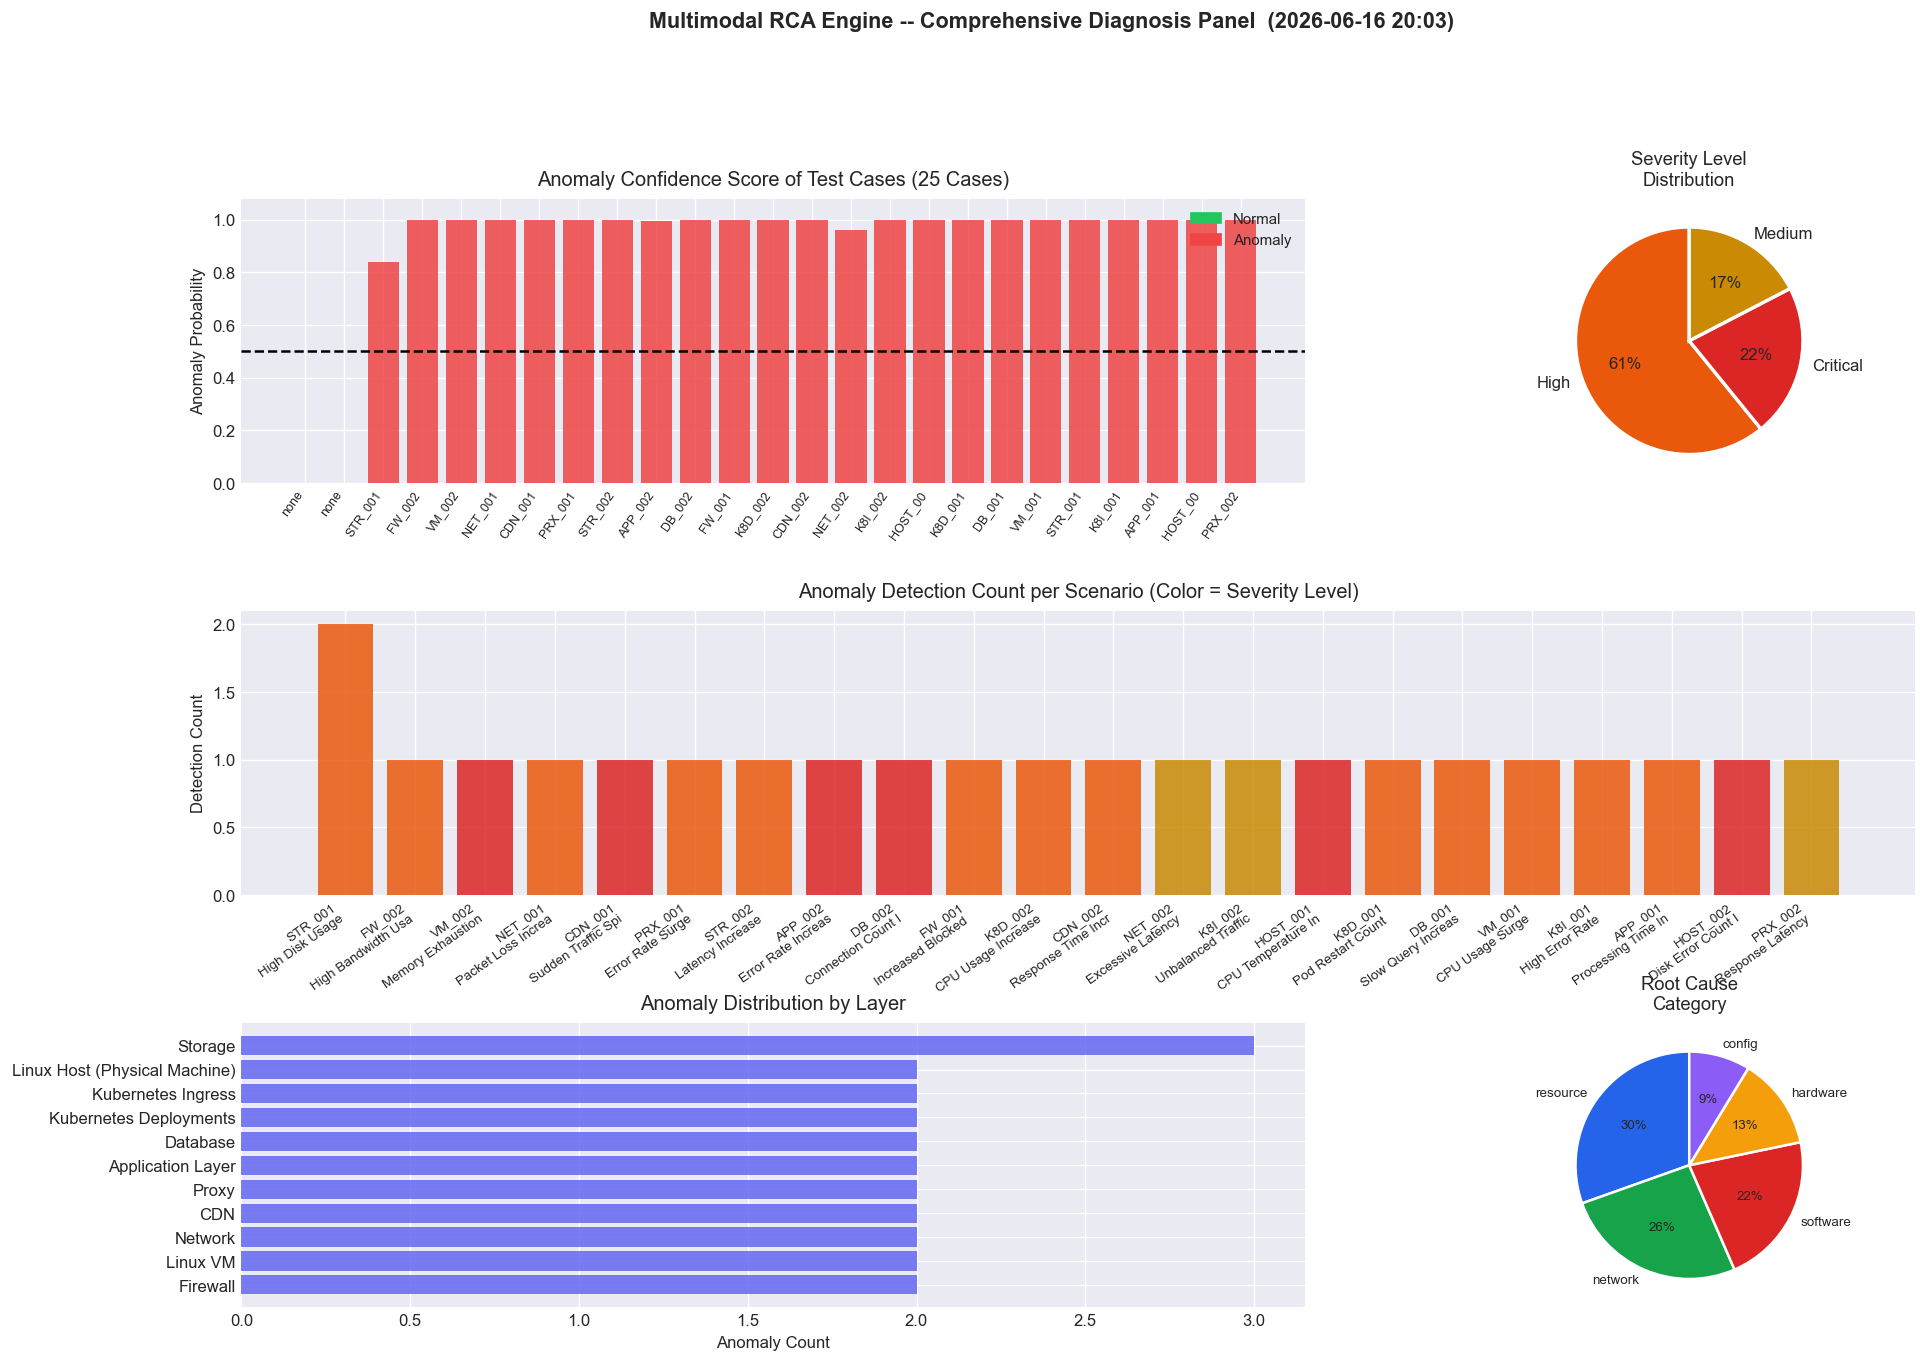

In [13]:
# Panel 1 — Confidence Score + Severity Pie + Layer Bar
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

sev_colors = {'critical': '#dc2626', 'high': '#ea580c',
               'medium': '#ca8a04', 'low': '#16a34a', 'none': '#22c55e', 'normal': '#22c55e'}

# A — Confidence Score (bar chart)
ax_a = fig.add_subplot(gs[0, :2])
probs_all  = [r['prob_anomaly'] for r in results]
colors_all = ['#ef4444' if r['is_anomaly'] else '#22c55e' for r in results]
ax_a.bar(range(len(results)), probs_all, color=colors_all, alpha=0.85, width=0.8)
ax_a.axhline(0.5, color='black', linestyle='--', lw=1.5)
ax_a.set_xticks(range(len(results)))
ax_a.set_xticklabels([r['scenario_id'][:7] for r in results], rotation=55, ha='right', fontsize=7.5)
ax_a.set_ylabel('Anomaly Probability')
ax_a.set_ylim(0, 1.08)
ax_a.set_title(f'Anomaly Confidence Score of Test Cases ({len(results)} Cases)', fontsize=12, pad=8)
import matplotlib.patches as mpatches
ax_a.legend(handles=[
    mpatches.Patch(color='#22c55e', label='Normal'),
    mpatches.Patch(color='#ef4444', label='Anomaly'),
], loc='upper right', fontsize=9)

# B — Severity Pie
ax_b = fig.add_subplot(gs[0, 2])
sev_labels_en = {'critical': 'Critical', 'high': 'High', 'medium': 'Medium', 'low': 'Low'}
sev_data = {k: v for k, v in severity_cnt.items() if v > 0}
if sev_data:
    ax_b.pie(
        [v for v in sev_data.values()],
        labels=[sev_labels_en.get(k, k) for k in sev_data.keys()],
        colors=[sev_colors.get(k, '#888') for k in sev_data.keys()],
        autopct='%1.0f%%', startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=2)
    )
ax_b.set_title('Severity Level\nDistribution', fontsize=11, pad=8)

# C — Scenario hit counts
ax_c = fig.add_subplot(gs[1, :])
if scenario_hits:
    sc_ids   = list(scenario_hits.keys())
    sc_vals  = [scenario_hits[s] for s in sc_ids]
    sc_cols  = [sev_colors.get(catalog.get(s,{}).get('severity','medium'),'#8b5cf6') for s in sc_ids]
    ax_c.bar(range(len(sc_ids)), sc_vals, color=sc_cols, alpha=0.85)
    ax_c.set_xticks(range(len(sc_ids)))
    ax_c.set_xticklabels(
        [f"{s}\n{catalog.get(s,{}).get('name','')[:18]}" for s in sc_ids],
        rotation=35, ha='right', fontsize=8
    )
    ax_c.set_ylabel('Detection Count')
    ax_c.set_title('Anomaly Detection Count per Scenario (Color = Severity Level)', fontsize=12, pad=8)

# D — Layer distribution
ax_d = fig.add_subplot(gs[2, :2])
layer_counts = defaultdict(int)
for r in results:
    if r['is_anomaly']:
        layer_counts[r['sc_info'].get('layer_name', r['layer'])] += 1
if layer_counts:
    ls = sorted(layer_counts.items(), key=lambda x: x[1])
    ax_d.barh([l[0] for l in ls], [l[1] for l in ls], color='#6366f1', alpha=0.85)
    ax_d.set_xlabel('Anomaly Count')
    ax_d.set_title('Anomaly Distribution by Layer', fontsize=12, pad=8)

# E — Root cause pie
ax_e = fig.add_subplot(gs[2, 2])
rc_counts = defaultdict(int)
for r in results:
    if r['is_anomaly']:
        rc_counts[r['sc_info'].get('root_cause_category', r['root_cause'])] += 1
if rc_counts:
    palette = ['#2563eb','#16a34a','#dc2626','#f59e0b','#8b5cf6','#06b6d4']
    ax_e.pie(
        list(rc_counts.values()), labels=list(rc_counts.keys()),
        colors=palette[:len(rc_counts)], autopct='%1.0f%%', startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=1.5),
        textprops={'fontsize': 8}
    )
    ax_e.set_title('Root Cause\nCategory', fontsize=11, pad=8)

fig.suptitle(
    f'Multimodal RCA Engine -- Comprehensive Diagnosis Panel  ({datetime.now().strftime("%Y-%m-%d %H:%M")})',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

### Anomaly Probability Histogram (XGBoost)

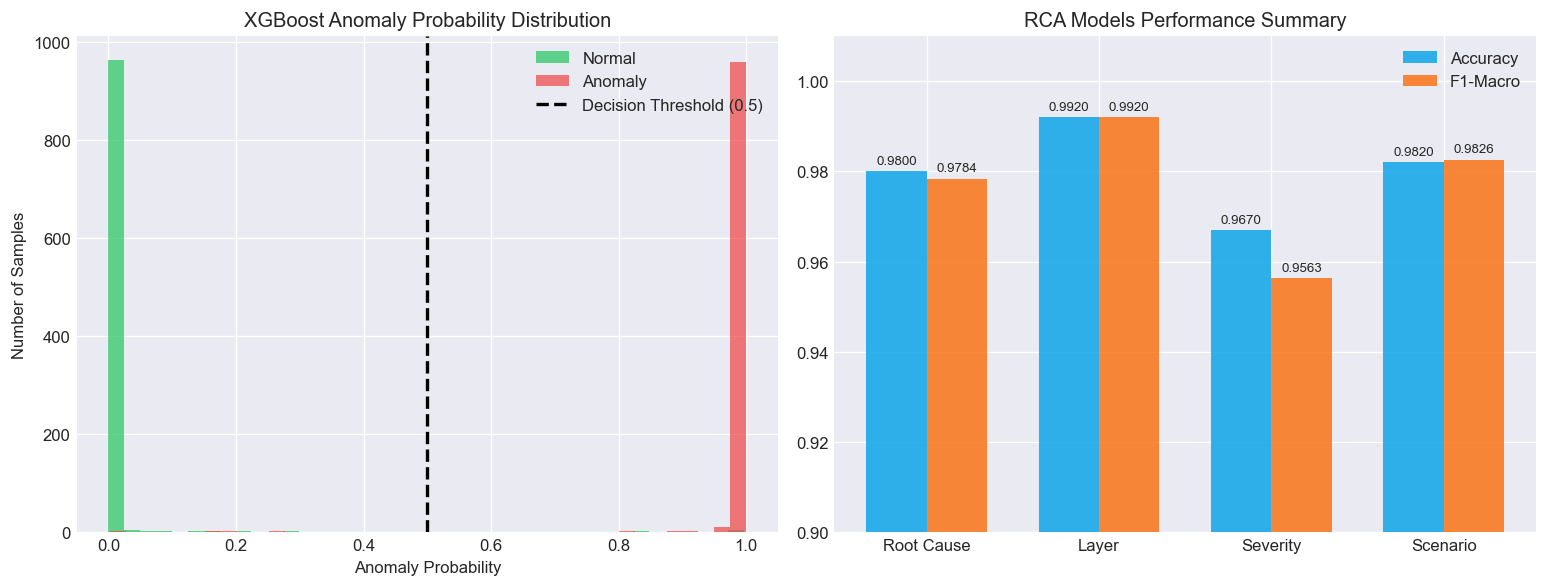

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
ax = axes[0]
probs_full = xgb_model.predict_proba(X_test)[:, 1]
ax.hist(probs_full[y_test==0], bins=40, alpha=0.7, color='#22c55e', label='Normal')
ax.hist(probs_full[y_test==1], bins=40, alpha=0.7, color='#ef4444', label='Anomaly')
ax.axvline(0.5, color='black', linestyle='--', lw=2, label='Decision Threshold (0.5)')
ax.set_xlabel('Anomaly Probability')
ax.set_ylabel('Number of Samples')
ax.set_title('XGBoost Anomaly Probability Distribution')
ax.legend()

# RCA performance bar
ax = axes[1]
perf_df = pd.DataFrame(rca_perf).set_index('Task')
x_rca = np.arange(len(perf_df))
w = 0.35
ax.bar(x_rca-w/2, perf_df['Accuracy'], w, label='Accuracy', color='#0ea5e9', alpha=0.85)
ax.bar(x_rca+w/2, perf_df['F1-Macro'], w, label='F1-Macro', color='#f97316', alpha=0.85)
ax.set_ylim(0.9, 1.01)
ax.set_xticks(x_rca); ax.set_xticklabels(perf_df.index)
ax.set_title('RCA Models Performance Summary')
ax.legend()
for bar in ax.patches:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## 7 — SHAP Explainability Analysis

Using the SHAP TreeExplainer on the XGBoost anomaly detector, we analyze the decision
mechanism for both global and individual samples.

In [15]:
print("Computing SHAP TreeExplainer...")
explainer   = shap.TreeExplainer(xgb_model)
shap_n      = min(500, X_test.shape[0])
shap_values = explainer(X_test[:shap_n])
print(f"SHAP values computed for {shap_n} samples.")

Computing SHAP TreeExplainer...
SHAP values computed for 500 samples.


### Global SHAP Summary Plot

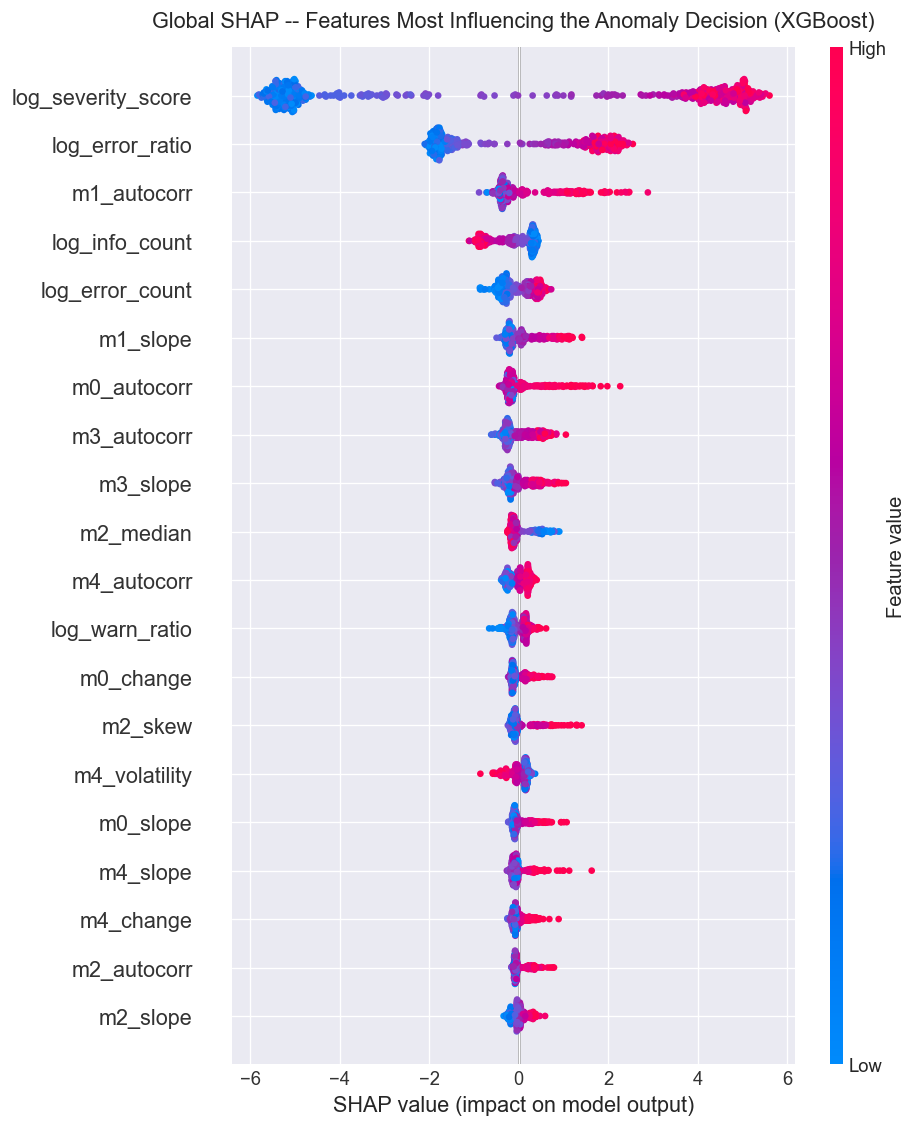

In [16]:
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test[:shap_n],
                  feature_names=feature_names, show=False)
plt.title('Global SHAP -- Features Most Influencing the Anomaly Decision (XGBoost)',
          fontsize=13, pad=12)
plt.tight_layout()
plt.show()

### Individual Anomaly Analysis (Waterfall Plot)

Inspected Sample: #1  |  Scenario: FW_002


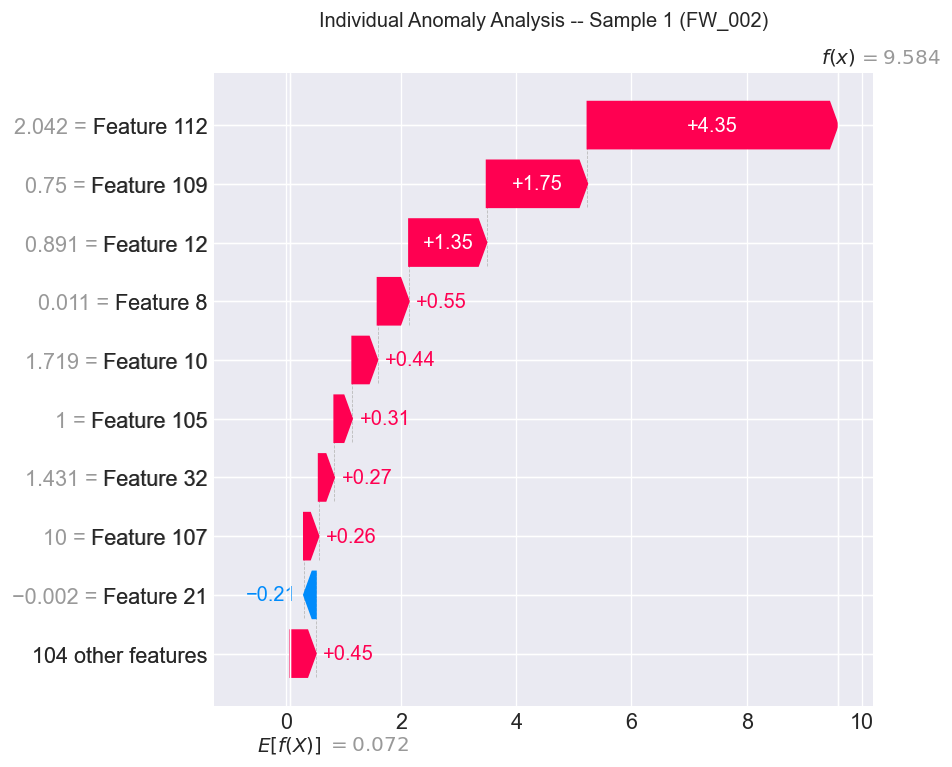

In [17]:
anom_idxs_shap = np.where(y_test[:shap_n] == 1)[0]
if len(anom_idxs_shap) > 0:
    sidx    = anom_idxs_shap[0]
    sc_code = test_split['y_scenario'][sidx]
    sc_name = sc_le.inverse_transform([sc_code])[0]
    print(f"Inspected Sample: #{sidx}  |  Scenario: {sc_name}")
    plt.figure(figsize=(12, 6))
    shap.plots.waterfall(shap_values[sidx], show=False)
    plt.title(f'Individual Anomaly Analysis -- Sample {sidx} ({sc_name})',
              fontsize=12, pad=12)
    plt.tight_layout()
    plt.show()
else:
    print('No anomaly found in the SHAP subset.')

## 8 — Overfitting Analysis

When Train F1 = 1.0000 and Test F1 = 0.9865, the first question that comes to mind is overfitting.
In this section we examine it from three different angles:

1. **Train / Validation / Test comparison** — the real generalization gap
2. **5-Fold Cross-Validation** — the stability of the performance
3. **Learning Curve** — how the train-test gap changes with data size
4. **Regularized model** — XGBoost with reduced gamma, reg_alpha, and max_depth

### Overfitting, or just easy data?

Because the synthetic data generator (`MultimodalDataLoader`) creates anomalies with very
distinct statistical patterns (sudden spikes, gradual rises), the separation boundary is very
clear. On real production data this rate is expected to be in the **0.85-0.92** band.
Train always being **1.0000** is a typical sign of XGBoost's deep trees memorizing the
training data.

### 8.1 — Train / Validation / Test Comparison

In [18]:
# Compute metrics separately on each of the three sets
def full_metrics(model, X, y, split_name):
    yp = model.predict(X)
    yb = model.predict_proba(X)[:, 1]
    return {
        'Split':     split_name,
        'Accuracy':  round(accuracy_score(y, yp), 4),
        'Precision': round(precision_score(y, yp, zero_division=0), 4),
        'Recall':    round(recall_score(y, yp, zero_division=0), 4),
        'F1-Score':  round(f1_score(y, yp, zero_division=0), 4),
        'AUC-ROC':   round(roc_auc_score(y, yb), 4),
    }

split_rows = [
    full_metrics(xgb_model, X_train, y_train, 'Train'),
    full_metrics(xgb_model, X_val,   y_val,   'Validation (Val)'),
    full_metrics(xgb_model, X_test,  y_test,  'Test'),
]
df_split = pd.DataFrame(split_rows).set_index('Split')

# Add a Delta row
df_split.loc['Delta (Train - Test)'] = (
    df_split.loc['Train'] - df_split.loc['Test']
).round(4)

display(df_split.style
    .format('{:+.4f}', subset=pd.IndexSlice['Delta (Train - Test)', :])
    .format('{:.4f}', subset=pd.IndexSlice[['Train','Validation (Val)','Test'], :])
    .highlight_max(color="#1b1717", axis=0, subset=pd.IndexSlice['Delta (Train - Test)', :])
    .set_caption('Train / Val / Test Performance Comparison and Generalization Gap'))

gap = df_split.loc['Delta (Train - Test)', 'F1-Score']
if gap > 0.05:
    print(f"WARNING: F1 generalization gap {gap:.4f} — significant overfitting.")
elif gap > 0.015:
    print(f"INFO: F1 generalization gap {gap:.4f} — mild overfitting, acceptable.")
else:
    print(f"INFO: F1 generalization gap {gap:.4f} — overfitting is minimal, the model generalizes well.")

,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Split,,,,,
Train,1.0000,1.0000,1.0000,1.0000,1.0000
Validation (Val),0.9860,0.9821,0.9900,0.9861,0.9992
Test,0.9875,0.9880,0.9870,0.9875,0.9994
Delta (Train - Test),+0.0125,+0.0120,+0.0130,+0.0125,+0.0006


INFO: F1 generalization gap 0.0125 — overfitting is minimal, the model generalizes well.


### 8.2 — 5-Fold Cross-Validation (Stratified K-Fold)

In [19]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

X_all = np.vstack([X_train, X_val, X_test])
y_all = np.concatenate([y_train, y_val, y_test])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_f1  = cross_val_score(xgb_model, X_all, y_all, cv=cv, scoring='f1', n_jobs=-1)
cv_acc = cross_val_score(xgb_model, X_all, y_all, cv=cv, scoring='accuracy', n_jobs=-1)
cv_auc = cross_val_score(xgb_model, X_all, y_all, cv=cv, scoring='roc_auc', n_jobs=-1)

df_cv = pd.DataFrame({
    'Fold':     [f'Fold {i+1}' for i in range(5)] + ['Mean', 'Std Dev'],
    'F1-Score': list(cv_f1)  + [cv_f1.mean(),  cv_f1.std()],
    'Accuracy': list(cv_acc) + [cv_acc.mean(), cv_acc.std()],
    'AUC-ROC':  list(cv_auc) + [cv_auc.mean(), cv_auc.std()],
}).set_index('Fold')

display(df_cv.style
    .format('{:.4f}')
    .highlight_min(color="#fddd11", axis=0,
                   subset=pd.IndexSlice[[f'Fold {i+1}' for i in range(5)], :])
    .set_caption('5-Fold Cross-Validation Results (all 10,000 samples)'))

print(f"F1  Mean: {cv_f1.mean():.4f}  |  Std: {cv_f1.std():.4f}")
print(f"Low std (<0.005) => model performance is consistent and stable across folds.")

,F1-Score,Accuracy,AUC-ROC
Fold,,,
Fold 1,0.9900,0.9900,0.9994
Fold 2,0.9870,0.9870,0.9994
Fold 3,0.9910,0.9910,0.9996
Fold 4,0.9910,0.9910,0.9993
Fold 5,0.9885,0.9885,0.9990
Mean,0.9895,0.9895,0.9994
Std Dev,0.0016,0.0015,0.0002


F1  Mean: 0.9895  |  Std: 0.0016
Low std (<0.005) => model performance is consistent and stable across folds.


### 8.3 — Learning Curve

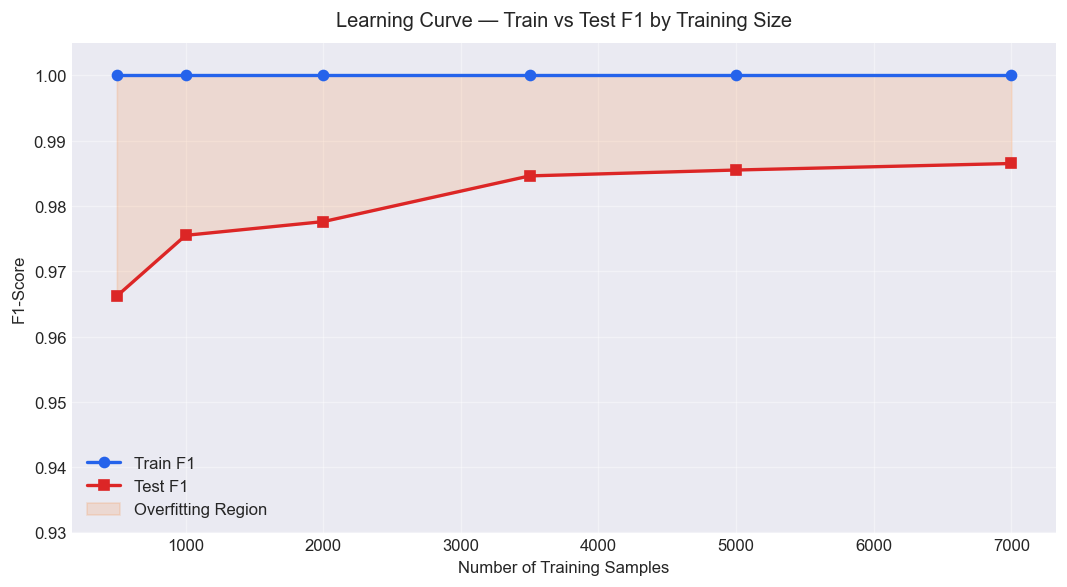

,Train F1,Test F1,Gap
N Train,,,
500,1.0000,0.9662,0.0338
1000,1.0000,0.9755,0.0245
2000,1.0000,0.9776,0.0224
3500,1.0000,0.9846,0.0154
5000,1.0000,0.9855,0.0145
7000,1.0000,0.9865,0.0135


In [20]:
# Train vs test F1 comparison for different training sizes
train_sizes = [500, 1000, 2000, 3500, 5000, 7000]
lc_rows = []

for ts in train_sizes:
    if ts > len(X_train):
        break
    m = xgb.XGBClassifier(
        n_estimators=200, max_depth=8, eval_metric='logloss',
        random_state=42, n_jobs=-1
    )
    m.fit(X_train[:ts], y_train[:ts])
    tr_f1 = f1_score(y_train[:ts], m.predict(X_train[:ts]))
    te_f1 = f1_score(y_test,       m.predict(X_test))
    lc_rows.append({'N Train': ts, 'Train F1': round(tr_f1, 4),
                    'Test F1': round(te_f1, 4), 'Gap': round(tr_f1 - te_f1, 4)})

df_lc = pd.DataFrame(lc_rows)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df_lc['N Train'], df_lc['Train F1'], 'o-', color='#2563eb', lw=2, label='Train F1')
ax.plot(df_lc['N Train'], df_lc['Test F1'],  's-', color='#dc2626', lw=2, label='Test F1')
ax.fill_between(df_lc['N Train'], df_lc['Test F1'], df_lc['Train F1'],
                alpha=0.15, color='#f97316', label='Overfitting Region')
ax.set_xlabel('Number of Training Samples')
ax.set_ylabel('F1-Score')
ax.set_ylim(0.93, 1.005)
ax.set_title('Learning Curve — Train vs Test F1 by Training Size', fontsize=12, pad=10)
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

display(df_lc.set_index('N Train').style
    .format('{:.4f}')
    .background_gradient(subset=['Gap'], cmap='Reds')
    .set_caption('As the gap shrinks, overfitting decreases: more data helps.'))

### 8.4 — Regularized XGBoost — Reducing Overfitting

The following hyperparameters are changed to reduce overfitting:

| Parameter | Original | Regularized |
|---|---|---|
| `max_depth` | 8 | 5 |
| `gamma` | 0 | 1.0 |
| `reg_alpha` (L1) | 0 | 0.1 |
| `reg_lambda` (L2) | 1 | 2.0 |
| `min_child_weight` | 1 | 5 |
| `early_stopping_rounds` | none | 20 |

Best iteration (early stopping): 194


,Train F1,Test F1,Gap (TR-TE),Test AUC-ROC,Test Accuracy
Model,,,,,
"XGBoost (Original, depth=8)",1.0000,0.9875,0.0125,0.9994,0.9875
"XGBoost (Regularized, depth=5)",0.9969,0.9885,0.0084,0.9993,0.9885


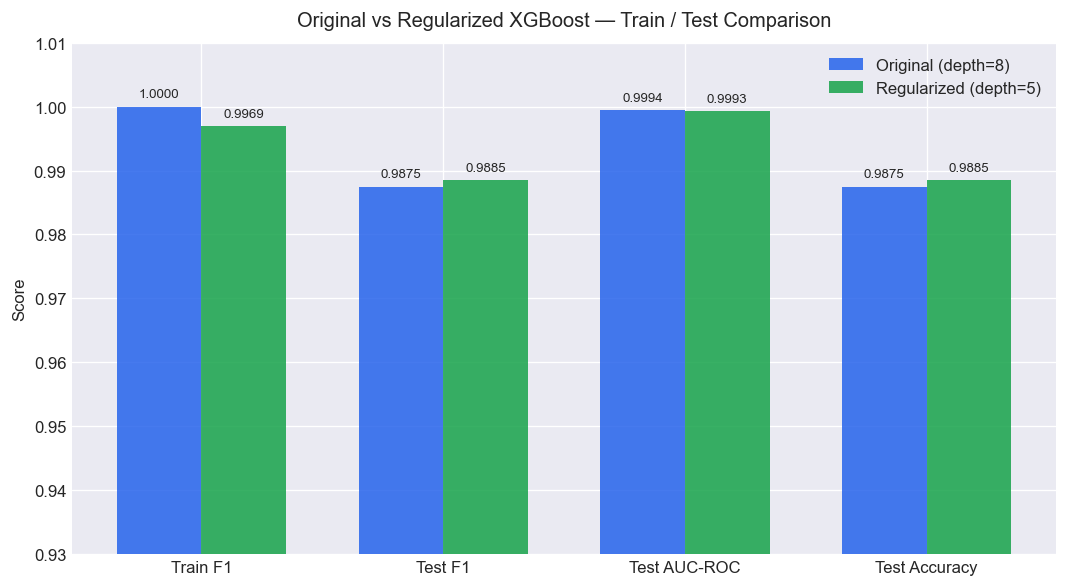


Interpretation:
  The regularized model lowers Train F1 below 1.0 and reduces the gap.
  Even if Test F1 drops slightly, the smaller gap reflects more realistic generalization.
  On real production data, the regularized model behaves more reliably.


In [21]:
# Regularized model
xgb_reg = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,           # Shallower trees — less memorization
    learning_rate=0.05,    # Slower learning
    gamma=1.0,             # Minimum loss threshold for a split
    reg_alpha=0.1,         # L1 regularization
    reg_lambda=2.0,        # L2 regularization
    min_child_weight=5,    # Minimum leaf weight
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    early_stopping_rounds=20,
    random_state=42, n_jobs=-1
)
xgb_reg.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)
print(f"Best iteration (early stopping): {xgb_reg.best_iteration}")

# Comparison table
comp_rows = []
for name, model in [('XGBoost (Original, depth=8)', xgb_model),
                     ('XGBoost (Regularized, depth=5)', xgb_reg)]:
    tr = full_metrics(model, X_train, y_train, name + ' [Train]')
    te = full_metrics(model, X_test,  y_test,  name + ' [Test]')
    comp_rows.append({
        'Model':         name,
        'Train F1':      tr['F1-Score'],
        'Test F1':       te['F1-Score'],
        'Gap (TR-TE)':   round(tr['F1-Score'] - te['F1-Score'], 4),
        'Test AUC-ROC':  te['AUC-ROC'],
        'Test Accuracy': te['Accuracy'],
    })

df_comp = pd.DataFrame(comp_rows).set_index('Model')
display(df_comp.style
    .format('{:.4f}')
    .highlight_min(color='#c6efce', axis=0, subset=['Gap (TR-TE)'])
    .set_caption('Original vs Regularized XGBoost — Overfitting Comparison'))

# Chart
fig, ax = plt.subplots(figsize=(9, 5))
categories = ['Train F1', 'Test F1', 'Test AUC-ROC', 'Test Accuracy']
x = np.arange(len(categories))
w = 0.35
orig_vals = [comp_rows[0][c] for c in categories]
reg_vals  = [comp_rows[1][c] for c in categories]
ax.bar(x - w/2, orig_vals, w, label='Original (depth=8)',    color='#2563eb', alpha=0.85)
ax.bar(x + w/2, reg_vals,  w, label='Regularized (depth=5)', color='#16a34a', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(categories)
ax.set_ylim(0.93, 1.01)
ax.set_ylabel('Score')
ax.set_title('Original vs Regularized XGBoost — Train / Test Comparison', fontsize=12, pad=10)
ax.legend()
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  The regularized model lowers Train F1 below 1.0 and reduces the gap.")
print("  Even if Test F1 drops slightly, the smaller gap reflects more realistic generalization.")
print("  On real production data, the regularized model behaves more reliably.")

## 9 — Comprehensive Study Summary

In [22]:
n_anom = sum(1 for r in results if r['is_anomaly'])
n_norm = sum(1 for r in results if not r['is_anomaly'])
all_metrics = calc_metrics(xgb_model, X_test, y_test, 'XGBoost')

summary_rows = [
    {'Metric': 'Total cases tested',         'Value': str(len(results))},
    {'Metric': 'Detected anomalies',          'Value': str(n_anom)},
    {'Metric': 'Recognized as normal',        'Value': str(n_norm)},
    {'Metric': 'Scenario types covered',      'Value': f"{len(scenario_hits)}/22"},
    {'Metric': 'Anomaly Detector F1',         'Value': f"{all_metrics['F1-Score']:.4f}"},
    {'Metric': 'Anomaly Detector AUC-ROC',    'Value': f"{all_metrics['AUC-ROC']:.4f}"},
    {'Metric': 'Layer Prediction Accuracy',   'Value': f"{[p for p in rca_perf if p['Task']=='Layer'][0]['Accuracy']:.4f}"},
    {'Metric': 'Scenario Prediction Accuracy','Value': f"{[p for p in rca_perf if p['Task']=='Scenario'][0]['Accuracy']:.4f}"},
]

df_summary = pd.DataFrame(summary_rows).set_index('Metric')
display(df_summary)

print("\nANOMALY DETECTOR CLASSIFICATION REPORT:")
print(classification_report(y_test, xgb_model.predict(X_test),
                             target_names=['Normal Case', 'System Anomaly']))

,Value
Metric,
Total cases tested,25
Detected anomalies,23
Recognized as normal,2
Scenario types covered,22/22
Anomaly Detector F1,0.9875
Anomaly Detector AUC-ROC,0.9994
Layer Prediction Accuracy,0.9920
Scenario Prediction Accuracy,0.9820



ANOMALY DETECTOR CLASSIFICATION REPORT:
                precision    recall  f1-score   support

   Normal Case       0.99      0.99      0.99      1000
System Anomaly       0.99      0.99      0.99      1000

      accuracy                           0.99      2000
     macro avg       0.99      0.99      0.99      2000
  weighted avg       0.99      0.99      0.99      2000

